In [8]:
import torch
import numpy as np

In [9]:
latent_sc = np.load('latent_sc_st/latent_sc.npy')
latent_st = np.load('latent_sc_st/latent_st.npy')

**************************************************
S: torch.Size([1000, 100, 2])
G: torch.Size([1000, 100, 2])


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:01<00:00, 282.37it/s]

Epoch 500: Loss -1.999197244644165
[[11.215762    1.3200845  -0.3078603  ...  0.5871077  -1.0629423
  -0.45904747]
 [-0.9304135  11.124427   -1.7032825  ...  1.3395966  -1.3550814
   0.6494989 ]
 [ 2.0504026  -1.6471374  11.703916   ...  1.4537835  -1.5655378
   1.5234576 ]
 ...
 [ 0.5919181   0.6950761  -2.8720083  ... 10.708531   -0.3790942
   0.76146626]
 [-2.355485   -0.2958837  -0.19075534 ... -0.985108   11.08677
   0.12397869]
 [-2.155044   -0.5184859   2.8763733  ... -0.8168177  -0.29629612
  11.345179  ]]


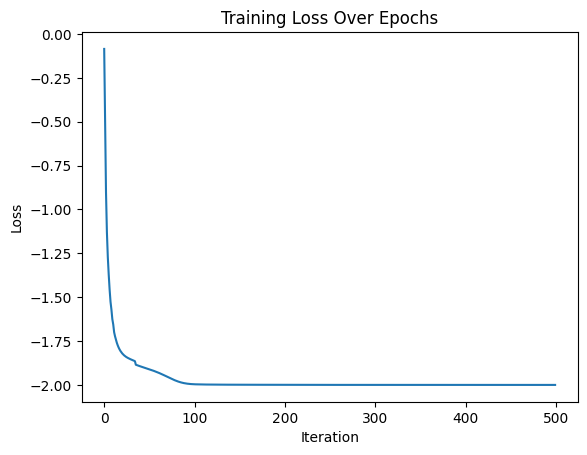

In [10]:
import sim_tangram.train_tangram as tg_cca
# tangram
tangram_sim, _ = tg_cca.read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0'), torch.tensor(latent_st, device='cuda:0')],
    [torch.tensor(latent_st, device='cuda:0'), torch.tensor(latent_sc, device='cuda:0')],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

**************************************************
S: torch.Size([1000, 100, 1])
G: torch.Size([1000, 100, 1])


 45%|████▌     | 227/500 [00:00<00:00, 2263.57it/s]

100%|██████████| 500/500 [00:00<00:00, 2259.97it/s]

Epoch 500: Loss -0.9453381299972534
[[10.238392   -1.124556   -1.5818082  ...  6.328779   -1.7858143
  -0.2828075 ]
 [-2.8642547  10.900781    0.28724453 ...  0.01254164 -1.4567754
   1.5111903 ]
 [ 0.48525473  8.212785   10.009548   ...  2.1943917  -1.8595114
   0.21236336]
 ...
 [-0.1417971  -0.38112864 -1.5344406  ...  9.684719   -1.2906091
   1.7412447 ]
 [-2.8452923  -0.9076231  -1.6911384  ... -1.2156305   9.862185
   0.9042521 ]
 [-0.6891047   4.4099708   1.2382277  ...  0.83151925 -1.1828238
  10.477731  ]]


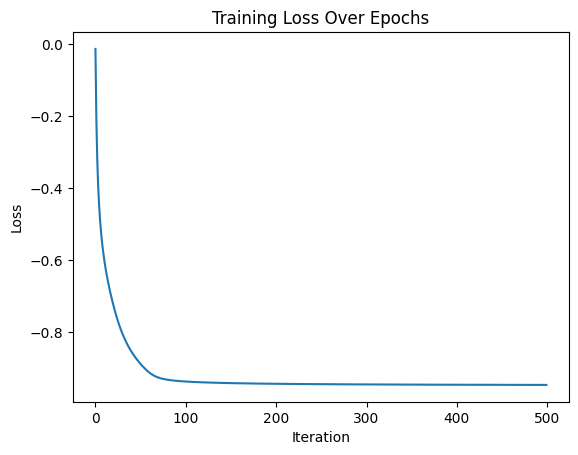

In [11]:
# 用cosine_similarity驱动的tangram进行计算

import cos_tg.train_tangram as tg_cos

# tangram
cos_sim_tg, _ = tg_cos.read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0')],
    [torch.tensor(latent_st, device='cuda:0')],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=0,
)

In [12]:
# 计算cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity
cos = cosine_similarity(latent_sc, latent_st)
cos_mapping = cos.argmax(axis=1)
for i in range(len(cos_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_mapping[i]:4d}", end="\t")
print()
print('*'*50)

# 检验cosine_similarity驱动的tangram
cos_tg_mapping = cos_sim_tg.argmax(axis=1)
for i in range(len(cos_tg_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_tg_mapping[i]:4d}", end="\t")
print()
print('*'*50)

# 检验CCA驱动的tangram
tangram_mapping = tangram_sim.argmax(axis=1)
for i in range(len(tangram_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {tangram_mapping[i]:4d}", end="\t")
print()
print('*'*50)



 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	
**************************************************

 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	
**************************************************

 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:  230	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	
**************************************************


In [13]:
# 计算acc
sample_size = 1000
gt = np.array(range(sample_size))
cos_acc = np.sum(cos_mapping == gt) / sample_size
tangram_acc = np.sum(tangram_mapping == gt) / sample_size
cos_tg_acc = np.sum(cos_tg_mapping == gt) / sample_size

print("cos accuracy:", cos_acc)
print("tangram accuracy:", tangram_acc)
print("cos_tg accuracy:", cos_tg_acc)


cos accuracy: 1.0
tangram accuracy: 0.996
cos_tg accuracy: 1.0


In [14]:
# from torch.nn.functional import cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity

a = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)
b = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)
print(cosine_similarity(a, b))

[[0.9999999 0.9746318]
 [0.9746318 1.       ]]
